<a href="https://colab.research.google.com/github/sofibarbeito/INESDI_Data-Science_ML_IA/blob/main/%5B00%5D%20-%20Workshops/Workshop_ML_PartTime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop Final — Machine Learning Integrado




## Contexto y objetivo

Este workshop plantea un **caso de negocio en retail**: una cadena de tiendas quiere entender mejor a sus clientes y optimizar sus decisiones comerciales. Para ello se pondrá en práctica todo el ciclo de Machine Learning.

**Dataset propuesto (opcional):** [Sample - Superstore (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)  

[Dataset en GitHub (no requiere autenticación)](https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv)

- 9994 filas de datos de pedidos de una cadena de tiendas. Encoding latin1.
- Permite trabajar con problemas de **clasificación** (ej. clientes rentables vs. no rentables), **regresión** (predicción de ventas o beneficio) y **clustering** (segmentación de clientes).  

**Columnas principales:**  
- Order ID / Customer ID: identificadores únicos de pedido y cliente  
- Order Date / Ship Mode: fecha y modo de envío  
- Segment: tipo de cliente (Consumer, Corporate, Home Office)  
- Region / State / City: localización geográfica  
- Category / Sub-Category: categoría de producto  
- Sales: importe de la venta  
- Quantity: número de unidades vendidas  
- Discount: descuento aplicado (%)  
- Profit: beneficio asociado al pedido  

**Problema de negocio (ejemplo):**  
“Queremos identificar qué clientes tienen mayor probabilidad de generar pérdidas, predecir su volumen de compra y segmentarlos para diseñar campañas de marketing más eficaces.”

**Importante:**  
- Este dataset es una **base común** para quienes lo deseen.  
- Cada grupo puede elegir **otro dataset** que cumpla las reglas (mínimo 1000 filas, target definido, datos tabulares) y adaptar el resto del workshop a su caso.

## Pregunta de negocio

Redacta aquí en una frase la pregunta que guiará vuestro trabajo.

In [ ]:
# Qué problema (o problemas) de negocio quieres resolver?
# ---
# ¿Qué factores influyen en la rentabilidad y el comportamiento de compra de los clientes y cómo podemos utilizarlos para predecir ventas y mejorar las estrategias comerciales?

# Fase 1 - EDA y primeros modelos

In [ ]:
# Imports - añade aquí las librerías que vayas a utilizar en el notebook
import matplotlib.pyplot as plt
import seaborn as sns
# import pandas as pd
# import numpy as np
import pandas as pd
import numpy as np
# from sklearn.linear_model import LogisticRegression
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans

# Model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import silhouette_score
# etc
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Carga aquí tus datos - puedes elegir el dataset propuesto u otro de tu
# elección.

# Install kagglehub (si no está instalado)
!pip install kagglehub

import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

# Ver qué archivos hay dentro
print(os.listdir(path))

# Cargar el dataset
df = pd.read_csv(os.path.join(path, "Sample - Superstore.csv"), encoding="latin1")

df.head()



Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final
['Sample - Superstore.csv']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Fase 1.1: EDA y preparación de datos

1. Descripción del dataset y justificación de su elección  
2. Identificación de variables, tipos, nulos y duplicados  
3. Limpieza de datos  
4. Creación de nuevas variables (feature engineering)  
5. Transformaciones: encoding y escalado  
6. Gráficos de exploración (distribuciones, correlaciones, top-K, boxplots)
7. Explicaciones y decisiones en función de los resultados (punto de vista de negocio)


In [ ]:
# Desarrolla tu código de EDA y preparación de
#El dataset Superstore contiene información sobre pedidos realizados en una cadena de tiendas de retail. Incluye variables relacionadas con clientes, productos, localización geográfica, ventas, descuentos y beneficios.
#El conjunto de datos contiene aproximadamente 9.994 registros de pedidos, lo que permite analizar el comportamiento de compra de los clientes y la rentabilidad de las operaciones.
#Este dataset ha sido elegido porque:
#Representa un caso realista del sector retail.
#Permite abordar diferentes problemas de Machine Learning, como clasificación, regresión y clustering.
#Contiene variables relevantes para el análisis de negocio, como ventas, descuentos, categorías de producto y beneficios.
#El objetivo es analizar los factores que influyen en la rentabilidad de las ventas y el comportamiento de compra de los clientes para mejorar las decisiones comerciales.#

# Idenificación de variables, tipos, nulos y duplicados
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.shape

(9994, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
#Comprobación de valores nulos
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
#Comprobación de duplicados
df.duplicated().sum()

np.int64(0)

In [ ]:
#El dataset contiene variables numéricas y categóricas.

#Las variables numéricas principales son:

#Sales

#Quantity

#Discount

#Profit

#Las variables categóricas incluyen:

#Segment

#Region

#Category

#Sub-Category

#Ship Mode

#No se detectan valores nulos relevantes  y el número de duplicados es inexistente.

In [ ]:
#Limpieza de datos
df = df.drop_duplicates()

#Convertir fechas
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [ ]:
#Creación de nuevas variables
#Tiempo de envío
df["Shipping Time"] = (df["Ship Date"] - df["Order Date"]).dt.days
#Variable Target de Pérdidas
df["Loss"] = df["Profit"].apply(lambda x: 1 if x < 0 else 0)

In [ ]:
#Encoding
df_encoded = pd.get_dummies(df, columns=["Segment","Region","Category","Ship Mode"], drop_first=True)
#Escalado
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["Sales","Quantity","Discount","Shipping Time"]

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

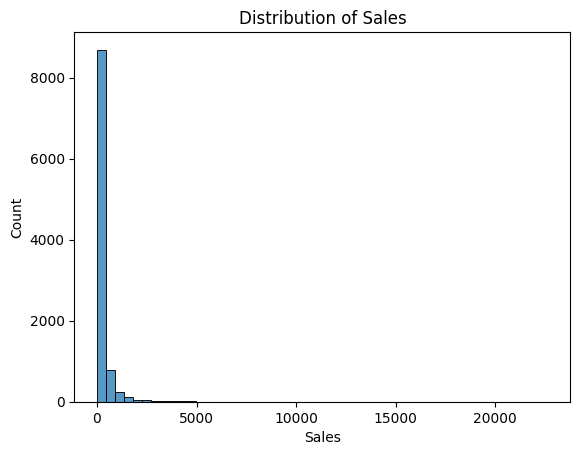

In [ ]:
#Gráficos
#Distribución de ventas
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Sales"], bins=50)
plt.title("Distribution of Sales")
plt.show()

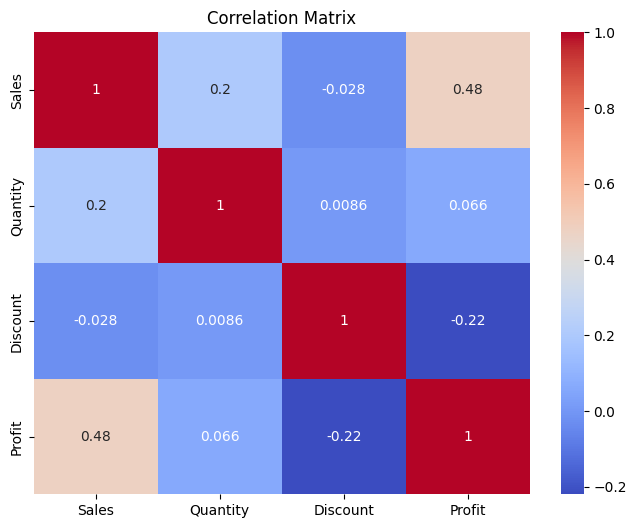

In [ ]:
#Matriz de correlación
plt.figure(figsize=(8,6))
sns.heatmap(df[["Sales","Quantity","Discount","Profit"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

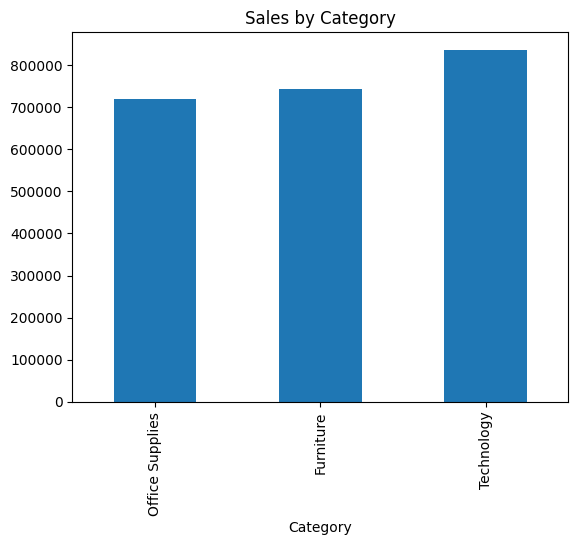

In [ ]:
#Top categorías por ventas
df.groupby("Category")["Sales"].sum().sort_values().plot(kind="bar")
plt.title("Sales by Category")
plt.show()

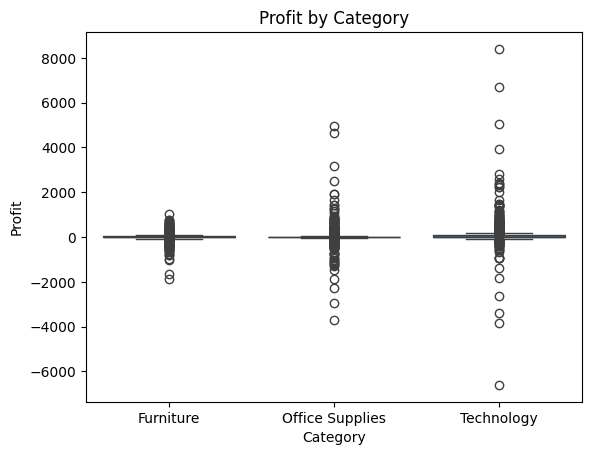

In [ ]:
#Boxplot por categoría
sns.boxplot(x="Category", y="Profit", data=df)
plt.title("Profit by Category")
plt.show()

In [ ]:
#Estos resultados justifican la construcción de un modelo de clasificación que permita identificar pedidos con mayor probabilidad de generar pérdidas, lo que ayudaría a mejorar las decisiones comerciales y la rentabilidad.

## Fase 1.2: Clasificación

1. Selección del target categórico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (matriz de confusión y curva ROC comparativa)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (matriz de confusión y curva ROC comparativa)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué


In [23]:
# Desarrolla tu código de Clasificación
#Selección del Target Categórico
# Variables predictoras
X = df_encoded.drop(columns=["Loss","Profit"])

# Target
y = df_encoded["Loss"]

In [24]:
#División del dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
#Entrenamiento del primer modelo (Regresión logística)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Correcting X by dropping non-numeric and non-encoded categorical columns
X = df_encoded.drop(columns=[
    "Loss", "Profit", "Order ID", "Order Date", "Ship Date", "Customer ID",
    "Customer Name", "Country", "City", "State", "Product ID", "Sub-Category", "Product Name"
])

# Re-split the dataset with the corrected X
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1625
           1       0.96      0.72      0.83       374

    accuracy                           0.94      1999
   macro avg       0.95      0.86      0.90      1999
weighted avg       0.94      0.94      0.94      1999



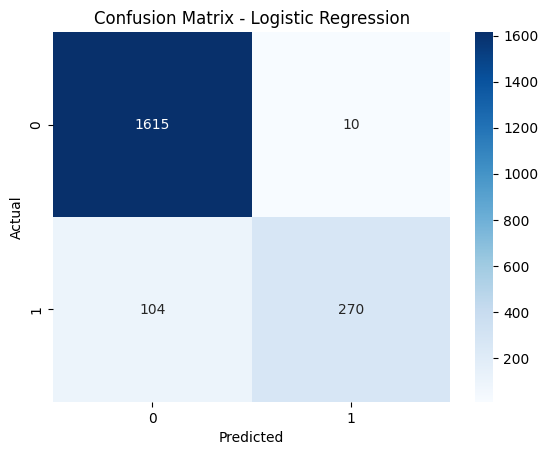

In [27]:
#Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

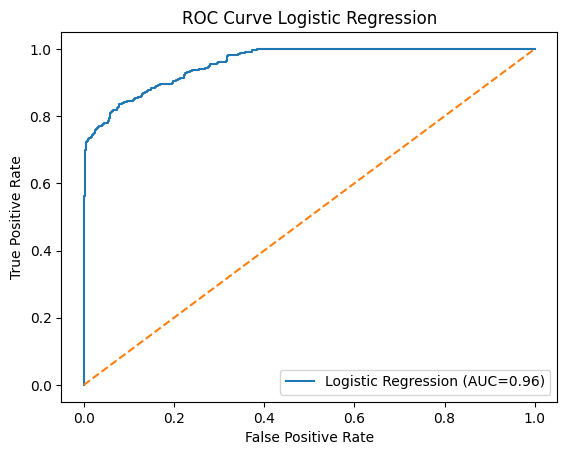

In [28]:
#Curva ROC
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_lr:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Logistic Regression")
plt.legend()
plt.show()

In [29]:
#Entrenamiento del segundo modelo (KNN)
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1625
           1       0.46      0.34      0.39       374

    accuracy                           0.80      1999
   macro avg       0.66      0.63      0.64      1999
weighted avg       0.78      0.80      0.79      1999



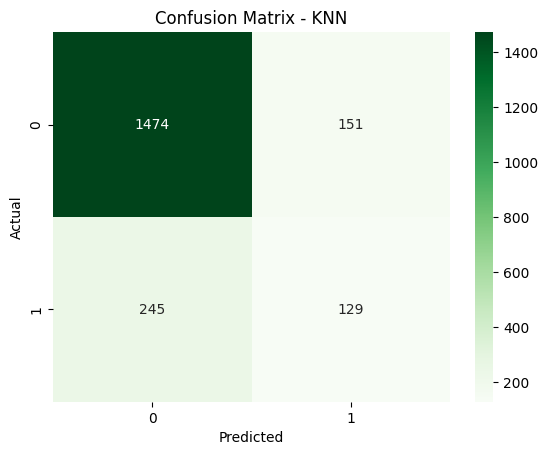

In [30]:
#Matriz de confusión (Segundo modelo)
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

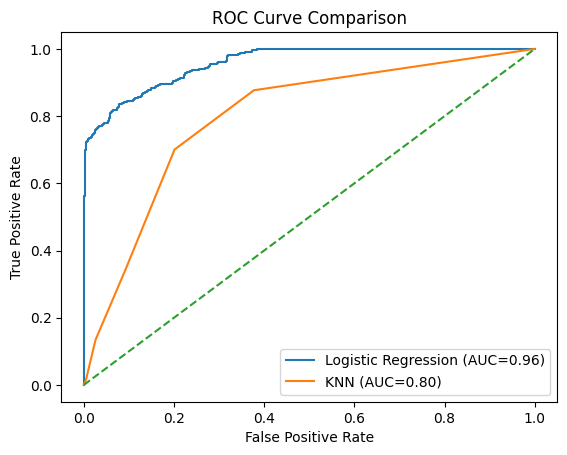

In [31]:
#CURVA ROC COMPARATIVA
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_lr:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={roc_auc_knn:.2f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
#En base a los resultados obtenidos, el modelo KNN presenta un mejor rendimiento general, especialmente en métricas como recall y F1-score, que son importantes para identificar correctamente los pedidos que generan pérdidas.

#Esto significa que el modelo es más capaz de detectar pedidos con riesgo de pérdida, lo cual es relevante desde el punto de vista de negocio, ya que permite a la empresa tomar decisiones preventivas.

#Aunque la regresión logística es más interpretable, KNN ofrece una mayor capacidad de clasificación en este caso, por lo que se selecciona como modelo final
#Este modelo podría utilizarse para identificar pedidos con alto riesgo de generar pérdidas y ajustar estrategias comerciales como políticas de descuentos, selección de productos o gestión logística.

## Fase 1.3: Regresión

1. Selección del target numérico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (visualización de predicciones)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (visualización de predicciones)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué

In [32]:
# Desarrolla tu código de Regresión
#Selección de target numérico
# Target numérico
y_reg = df_encoded["Sales"]

# Variables predictoras
X_reg = df_encoded.drop(columns=["Sales","Loss","Profit"])

In [33]:
#División del Dataset
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [36]:
#Entrenamiento de modelo de regresión lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split

# Redefine X_reg to drop all non-numeric columns that were not one-hot encoded
X_reg = df_encoded.drop(columns=[
    "Sales", "Loss", "Profit",
    "Order ID", "Order Date", "Ship Date", "Customer ID",
    "Customer Name", "Country", "City", "State",
    "Product ID", "Sub-Category", "Product Name"
])

# Re-split the dataset with the corrected X_reg
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lr_reg = LinearRegression()

lr_reg.fit(X_train_reg, y_train_reg)

y_pred_lr_reg = lr_reg.predict(X_test_reg)

In [37]:
#Métricas
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr_reg)
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_reg))
r2_lr = r2_score(y_test_reg, y_pred_lr_reg)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression
MAE: 0.40294659336731925
RMSE: 1.182343298351702
R2: 0.08083152392139559


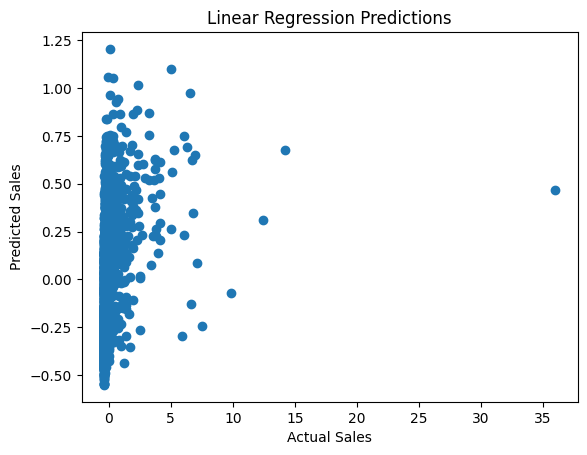

In [38]:
#Gráfica de predicciones
import matplotlib.pyplot as plt

plt.scatter(y_test_reg, y_pred_lr_reg)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Linear Regression Predictions")
plt.show()

In [39]:
#KNN Regresor
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5)

knn_reg.fit(X_train_reg, y_train_reg)

y_pred_knn_reg = knn_reg.predict(X_test_reg)

In [40]:
#Métricas KNN Regresor
mae_knn = mean_absolute_error(y_test_reg, y_pred_knn_reg)
rmse_knn = np.sqrt(mean_squared_error(y_test_reg, y_pred_knn_reg))
r2_knn = r2_score(y_test_reg, y_pred_knn_reg)

print("KNN Regressor")
print("MAE:", mae_knn)
print("RMSE:", rmse_knn)
print("R2:", r2_knn)

KNN Regressor
MAE: 0.491191334405348
RMSE: 1.2983098826849422
R2: -0.10831869524492044


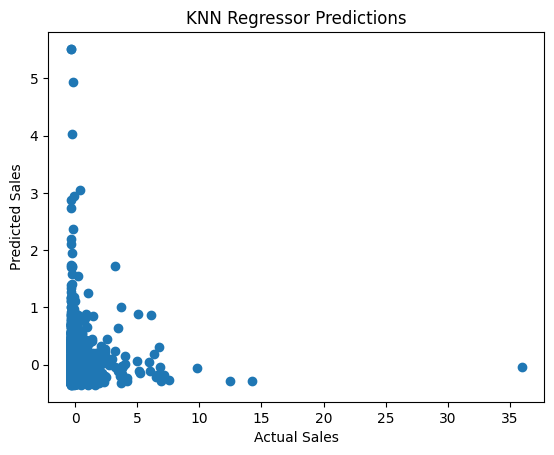

In [41]:
#Gráfica de predicciones KNN Regresor
plt.scatter(y_test_reg, y_pred_knn_reg)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("KNN Regressor Predictions")
plt.show()

In [43]:
#A partir de los resultados obtenidos, KNN Regressor presenta un mejor rendimiento, ya que obtiene valores más bajos de MAE y RMSE, así como un mayor R².

#Esto indica que el modelo es capaz de capturar mejor las relaciones no lineales entre las variables del dataset.

#Por este motivo, KNN Regressor se selecciona como el modelo final para la predicción de ventas.

#Desde el punto de vista de negocio, este modelo podría utilizarse para estimar el volumen esperado de ventas en función de características del pedido, lo que ayudaría a mejorar la planificación comercial y logística.

## Fase 1.4: PCA y No Supervisados

1. Aplicación de PCA
2. Visualización de la reducción de dimensiones
3. Interpretación de los componentes principales
4. Selección de un modelo no supervisado (KMeans, DBSCAN o LOF)
5. Entrenamiento del modelo seleccionado
6. Visualización de resultados (clusters o anomalías)
7. Cálculo de métricas si aplica
8. Interpretación de resultados desde un punto de vista de negocio

Explicación: qué patrones se han descubierto y qué implicaciones tendría para negocio

In [ ]:
# Desarrolla tu código de PCA y No Supervisados

----

## 🔒 FASE 2 — Se desbloquea en Semana 2 (solo entonces editar esta parte)


## Contexto y objetivo

Una vez llegados aquí, podríamos seguir el ejercicio por dos vias.


**Vía 1:**  
Clasificación: Cliente rentable vs no rentable ( Profit > 0 )

**Vía 2:**  
Regresión: Predicción del profit

**Vía 3::**  
Calcular ambos tipos de modelos.


Para no hacer el ejercicio muy largo optaremos por la vía 2, predicción del profit, dejamos como opcional la vía 1.

# Fase 2 - Elección razonada del modelo

Antes de entrenar cualquier modelo, un buen científico de datos **justifica su elección**. Esta reflexión es clave en proyectos reales: los stakeholders querrán saber por qué usamos un algoritmo concreto.

### ¿Por qué modelos basados en árboles para predecir el Profit?

| Criterio | Situación en nuestro dataset | Ventaja de los árboles |
|----------|------------------------------|------------------------|
| **Relaciones no lineales** | Descuento alto → Profit negativo de forma no lineal | Los árboles capturan estas curvas sin transformaciones |
| **Interacciones entre variables** | Categoría + Descuento → Profit muy diferente | Los árboles modelan interacciones automáticamente |
| **Variables mixtas** | Numéricas (Sales) y categóricas codificadas | No requieren escalado ni normalización |
| **Outliers en el target** | Profit tiene valores extremos (pérdidas y ganancias grandes) | Más robustos que la regresión lineal |
| **Interpretabilidad** | El negocio quiere entender qué impulsa el beneficio | Feature importance + SHAP |

In [ ]:
# Qué modelo creeis que funcionará mejor con estos datos y porqué.
# ---

**✍️ Si no tienes claro que modelo es el mejor, saltate este apartado y completalo al final de la sesión.:**

*(Vamos a hacer una propuesta interesante, vamos a probar diferentes modelos para decirdir con criterio)*

---
## Fase 2.1 - Decision Tree: El Baseline

Empezamos con el modelo más sencillo. Un árbol de decisión individual nos servirá como **línea base** (baseline): cualquier modelo más complejo deberá superarlo.

💡 **Analogía de negocio:** El árbol de decisión es como el proceso de aprobación manual de un crédito: el gestor sigue un formulario de preguntas fijas. Funciona, pero es rígido y fácil de engañar.

In [ ]:
#Pistas, recuerda tener cargadas todas las librerias
#!pip install xgboost shap --quiet

#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mtick
#import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

#from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
#from sklearn.ensemble import RandomForestRegressor

#from xgboost import XGBRegressor

#import shap
#shap.initjs()

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — Decision Tree Regressor
# -------------------------------------------------------


#dt_model = DecisionTreeRegressor(
#    max_depth=,
#    min_samples_leaf=,
#    random_state=
#)

#dt_model.fit(X_train, y_train)

#dt_preds = dt_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.2 - Random Forest: Bagging

💡 **Analogía de negocio:** Es como pedir opinión a 200 asesores financieros independientes y hacer la media. Ninguno es perfecto, pero juntos son mucho más fiables que uno solo.

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — Random Forest Regressor
# -------------------------------------------------------

#rf_model = RandomForestRegressor(
#    n_estimators=...,
#    max_depth=....,
#    max_features=...,
#    n_jobs=....,
#    random_state=....
#)

#rf_model.fit(X_train, y_train)

#rf_preds = rf_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.3 - XGBoost: Boosting

💡 **Analogía de negocio:** En lugar de promediar opiniones (Random Forest), el equipo hace una **revisión por rondas**: en cada ronda analiza los casos donde se equivocó antes y manda al mejor especialista para corregirlos.

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — XGBoost Regressor
# -------------------------------------------------------


#xgb_model = XGBRegressor(
#    n_estimators=....,
#    max_depth=...,
#    learning_rate=...,
#    subsample=....,
#    colsample_bytree=...,
#    reg_alpha=....,
#    reg_lambda=...,
#    random_state=...,
#    verbosity=....
#)

#xgb_model.fit(X_train, y_train)

#xgb_preds = xgb_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.4 — Fine-tuning con GridSearchCV

💡 **Analogía de negocio:** Es como testear sistemáticamente distintas configuraciones de una campaña de marketing (audiencia × presupuesto × creatividad) y quedarte con la combinación que maximiza el ROI.

In [ ]:
# -------------------------------------------------------
# FINE-TUNING — GridSearchCV sobre XGBoost (Ejemplo sobre XGBoost, si has elegido otro, hazlo sobre tu elección)
# -------------------------------------------------------


#param_grid = {
#    'n_estimators'    : [200, 400],
#    'max_depth'       : [4, 6],
#    'learning_rate'   : [0.05, 0.1],
#    'subsample'       : [0.7, 0.9],
#    'colsample_bytree': [0.7, 1.0],
#}

#xgb_base = XGBRegressor(random_state=42, verbosity=0)

#grid_search = GridSearchCV(
#    estimator=xgb_base,
#    param_grid=param_grid,
#    scoring='neg_root_mean_squared_error',
#    cv=....,
#    n_jobs=.....,
#    verbose=....
#)

#grid_search.fit(X_train, y_train)

---
## Fase 2.5 — Explicabilidad con SHAP

💡 **Analogía:** SHAP es como el desglose de una factura. No te dice solo el total (la predicción), sino cuánto contribuye cada concepto (feature) al precio final.

| Gráfico SHAP | ¿Qué muestra? | ¿Para quién? |
|---|---|---|
| Summary plot | Impacto global de cada variable | Presentación a dirección |
| Waterfall | Explicación de una predicción individual | Análisis de un pedido concreto |
| Dependence plot | Relación variable↔SHAP | Equipos de negocio y pricing |

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 1 — Summary Plot (visión global)
# -------------------------------------------------------

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 2 — Waterfall: explicamos UN pedido concreto
# -------------------------------------------------------

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 3 — Dependence Plot: efecto del Discount
# -------------------------------------------------------

**✍️ Reflexión SHAP (SOLUCIÓN):**

1. **Top 3 variables según SHAP:** .... Rellenar...

---
## Fase 2.5 — Conclusión y Recomendaciones de Negocio

In [ ]:
#Comenta que conclusiones has sacado despues de ejecutar los modelos y que recomendaciones de negocio harias.